In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [2]:
df = pd.read_csv('./csv_data/loanfile.csv')

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [7]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].mean())

In [9]:
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mean())

In [10]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.shape

(542, 13)

<Axes: xlabel='Property_Area', ylabel='count'>

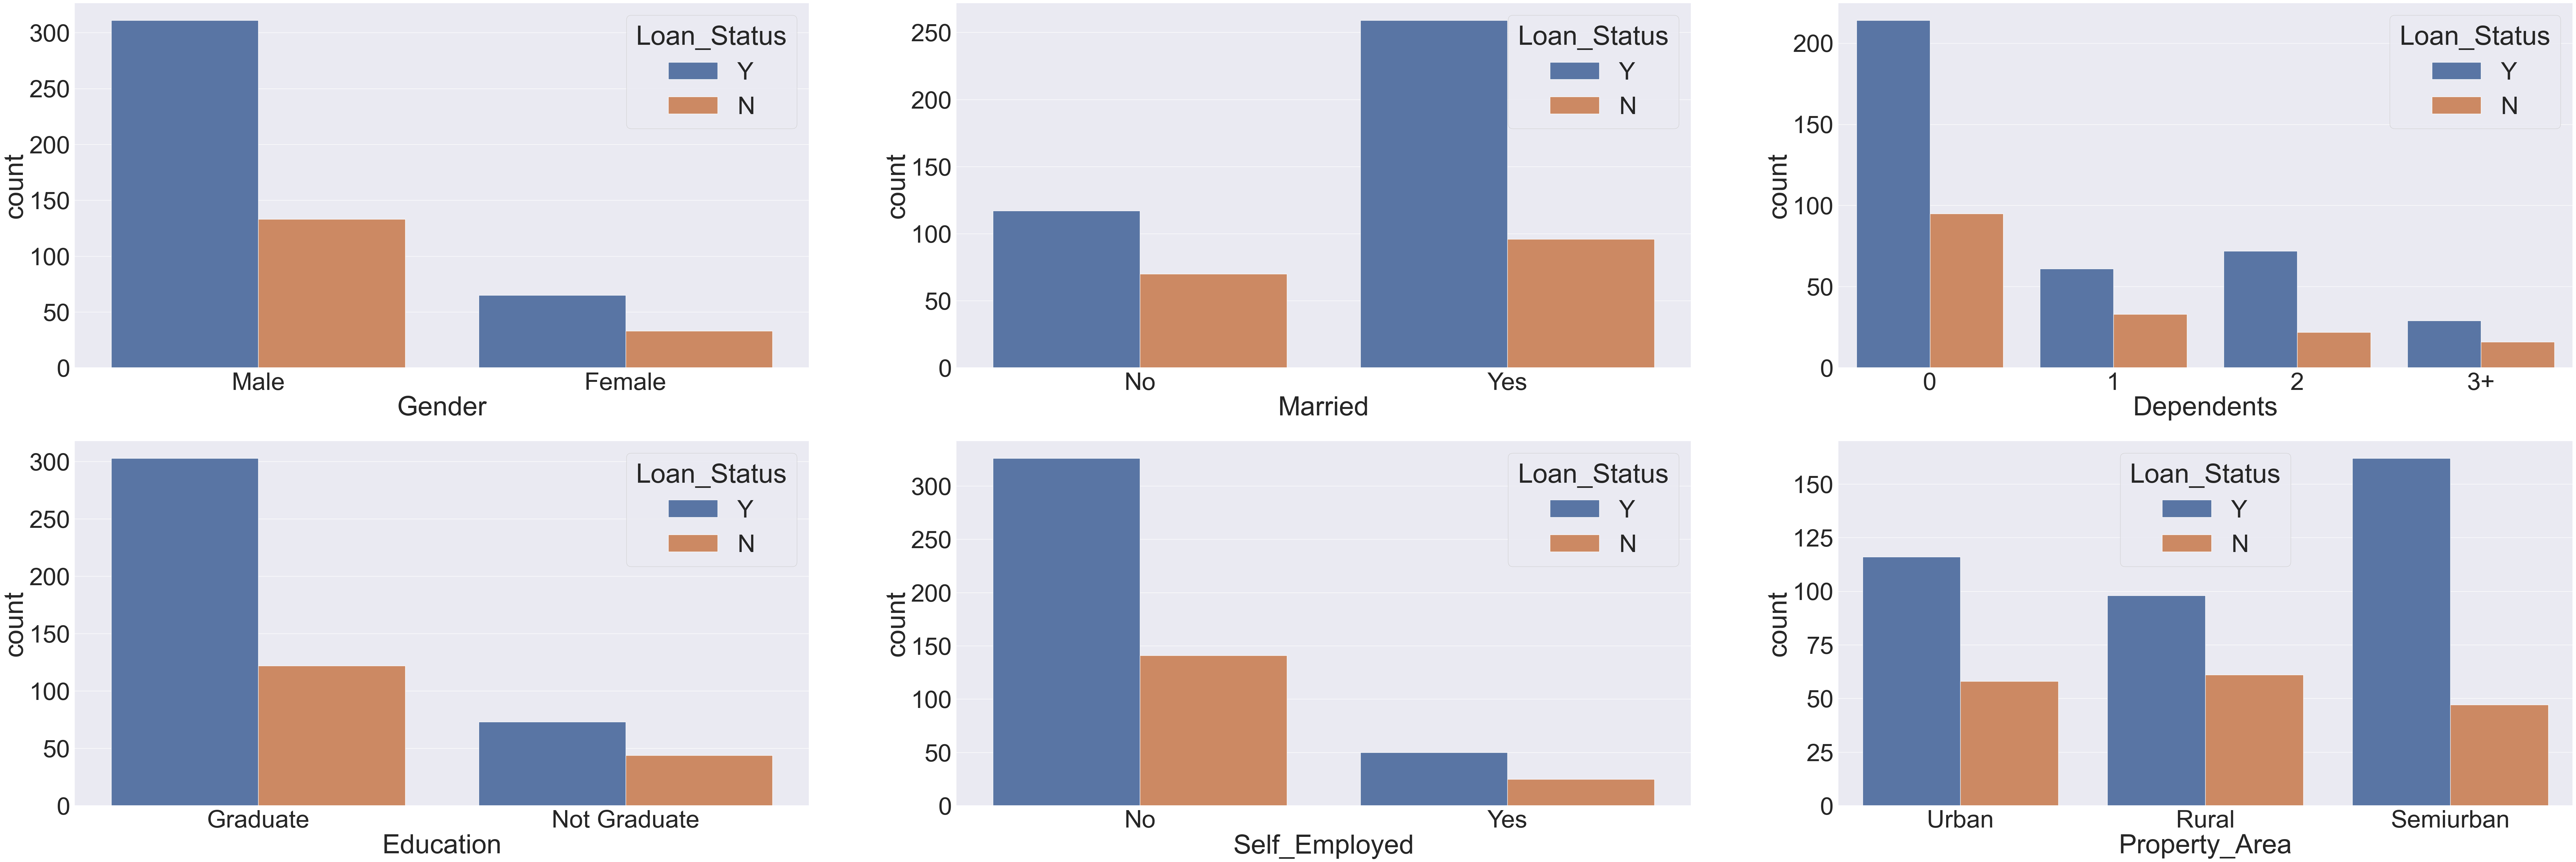

In [13]:
plt.figure(figsize = (100, 50))
sns.set(font_scale = 5)
plt.subplot(331)
sns.countplot(x = "Gender", hue = 'Loan_Status', data = df)
plt.subplot(332)
sns.countplot(x = "Married", hue = 'Loan_Status', data = df)
plt.subplot(333)
sns.countplot(x = "Dependents", hue = 'Loan_Status', data = df)
plt.subplot(334)
sns.countplot(x = "Education", hue = 'Loan_Status', data = df)
plt.subplot(335)
sns.countplot(x = "Self_Employed", hue = 'Loan_Status', data = df)
plt.subplot(336)
sns.countplot(x = "Property_Area", hue = 'Loan_Status', data = df)

In [14]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [15]:
df["Loan_Status"].value_counts()

Loan_Status
1    376
0    166
Name: count, dtype: int64

In [16]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Gender"].value_counts()

Gender
1    444
0     98
Name: count, dtype: int64

In [17]:
df['Married'] = df['Married'].map({"Yes": 1, "No": 0})
df["Married"].value_counts()

Married
1    355
0    187
Name: count, dtype: int64

In [18]:
df['Dependents'] = df['Dependents'].map({"0": 0, "1": 1, "2": 2, "3+": 3})
df["Dependents"].value_counts()

Dependents
0    309
1     94
2     94
3     45
Name: count, dtype: int64

In [19]:
df['Education'] = df['Education'].map({"Graduate": 1, "Not Graduate": 0})
df["Education"].value_counts()

Education
1    425
0    117
Name: count, dtype: int64

In [20]:
df['Property_Area'] = df['Property_Area'].map({"Rural": 0, "Semiurban": 1, "Urban": 2})
df["Property_Area"].value_counts()

Property_Area
1    209
2    174
0    159
Name: count, dtype: int64

In [21]:
df['Self_Employed'] = df['Self_Employed'].map({"Yes": 1, "No": 0})
df["Self_Employed"].value_counts()

Self_Employed
0    467
1     75
Name: count, dtype: int64

In [22]:
x = df.iloc[1:542, 1:12].values
y = df.iloc[1:542, 12].values

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)

In [24]:
model = LogisticRegression()
model.fit(x_train, y_train)
lr_pred = model.predict(x_test)

print("Accuracy:", metrics.accuracy_score(lr_pred, y_test))

Accuracy: 0.7914110429447853


e:\MCA\.venv-3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
print("y_predicted Values:", lr_pred)
print("y_test Values:", y_test)

y_predicted Values: [1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 0 1 0 0 1 1 1 1 0 1 1 1 0 1
 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1
 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1]
y_test Values: [1 0 1 1 1 0 0 1 1 1 1 1 0 1 1 0 1 0 1 0 0 1 1 0 1 0 0 0 1 0 1 0 1 1 0 0 1
 1 0 1 0 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 0 1 1 1 1 0 1
 1 0 1 0 0 1 0 1 1 1 1 0 0 1 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 0 0 1 1 0 1 1
 1 0 1 0 1 1 1 1 0 1 0 0 1 1 1]
